In [1]:
print("Project Started")

Project Started


In [1]:
import pandas as pd
from textblob import TextBlob

In [2]:
import pandas as pd

df = pd.read_csv("Reviews.csv", nrows=5000)

In [3]:
df.shape

(5000, 10)

In [4]:
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [5]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

In [6]:
df.shape

(5000, 10)

In [7]:
df.to_csv("Reviews_5000.csv", index=False)

In [8]:
df = df[['Text', 'Score']]

In [9]:
df.head(10)

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5
5,I got a wild hair for taffy and ordered this f...,4
6,This saltwater taffy had great flavors and was...,5
7,This taffy is so good. It is very soft and ch...,5
8,Right now I'm mostly just sprouting this so my...,5
9,This is a very healthy dog food. Good for thei...,5


In [10]:
df = df.dropna(subset=['Text'])

In [11]:
df = df.drop_duplicates(subset=['Text'])

In [12]:
df.shape

(4984, 2)

In [13]:
from textblob import TextBlob

In [14]:
def get_sentiment(text):
    analysis = TextBlob(text)
    score = analysis.sentiment.polarity
    
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [15]:
df['Sentiment'] = df['Text'].apply(get_sentiment)

In [16]:
df.head(10)

,Text,Score,Sentiment
0,I have bought several of the Vitality canned d...,5,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative
2,This is a confection that has been around a fe...,4,Positive
3,If you are looking for the secret ingredient i...,2,Positive
4,Great taffy at a great price. There was a wid...,5,Positive
5,I got a wild hair for taffy and ordered this f...,4,Positive
6,This saltwater taffy had great flavors and was...,5,Positive
7,This taffy is so good. It is very soft and ch...,5,Positive
8,Right now I'm mostly just sprouting this so my...,5,Positive
9,This is a very healthy dog food. Good for thei...,5,Positive


In [17]:
df['Sentiment'].value_counts()

Sentiment
Positive    4403
Negative     501
Neutral       80
Name: count, dtype: int64

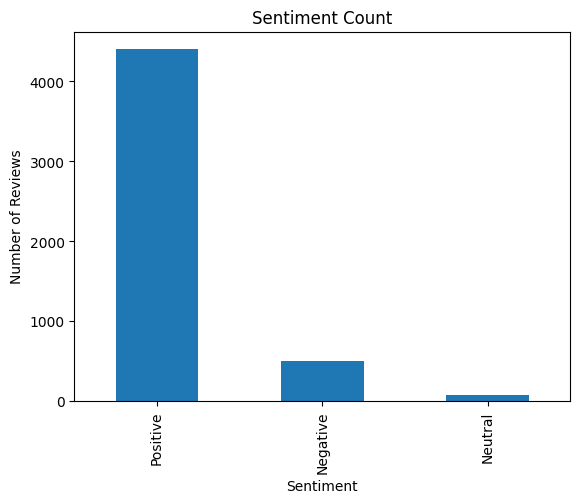

In [18]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

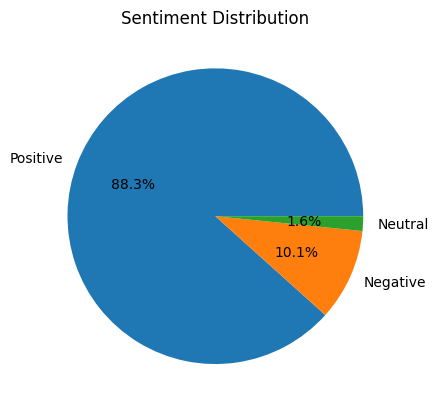

In [19]:
df['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

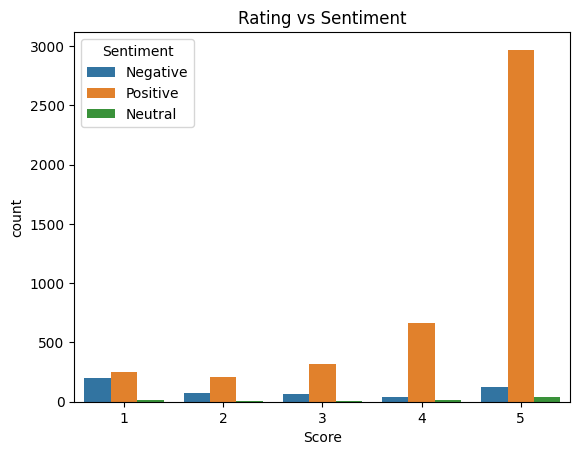

In [20]:
import seaborn as sns

sns.countplot(x='Score', hue='Sentiment', data=df)
plt.title("Rating vs Sentiment")
plt.show()

In [21]:
plt.savefig("chart1.png")

<Figure size 640x480 with 0 Axes>

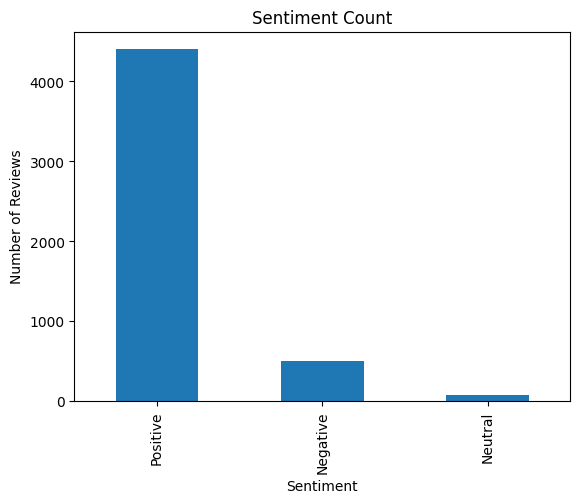

In [22]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.savefig("chart1.png")   # ✅ Save here
plt.show()

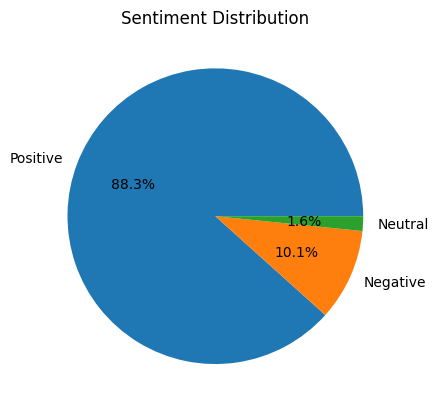

In [23]:
df['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Sentiment Distribution")
plt.ylabel("")

plt.savefig("chart2.png")   # ✅ Save here
plt.show()

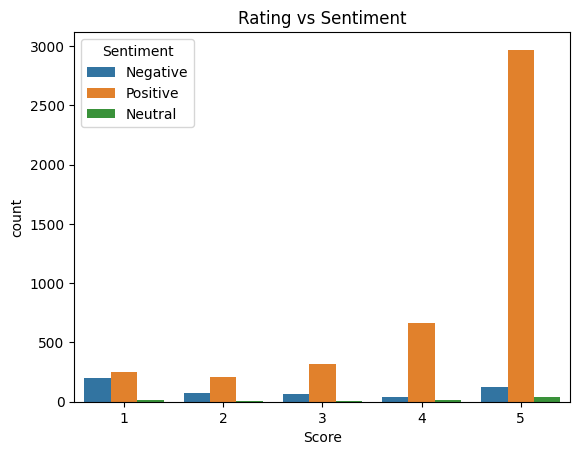

In [24]:
import seaborn as sns

sns.countplot(x='Score', hue='Sentiment', data=df)

plt.title("Rating vs Sentiment")

plt.savefig("chart3.png")   # ✅ Save here
plt.show()

## 📊 Insights & Summary

The sentiment analysis shows that approximately 88% of the reviews are positive, indicating high customer satisfaction. Around 10% of reviews are negative, while a small percentage 1.6% is neutral. Customers mainly complain about product quality issues, incorrect labeling, and products not meeting expectations. One surprising observation was that some low-rated reviews still had positive sentiment in the text, showing a mismatch between rating and actual feedback. Based on these findings, it is recommended that the business focus on improving product consistency and ensuring accurate product descriptions to reduce negative reviews.